# Classification of the eyes state based on EEG signals

In [109]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch
import optuna
from scipy.signal import medfilt
import matplotlib.pyplot as plt

## Load data

In [110]:
!pip install ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
from scipy.io import arff

file_name = "EEG Eye State.arff"
data, meta = arff.loadarff(file_name)
df = pd.DataFrame(data)
X = df.drop('eyeDetection', axis=1)
y =df['eyeDetection'].astype(np.int8)
X.head()


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [112]:
y

0        0
1        0
2        0
3        0
4        0
        ..
14975    1
14976    1
14977    1
14978    1
14979    1
Name: eyeDetection, Length: 14980, dtype: int8

In [113]:
# fetch dataset 
'''
eeg_eye_state = fetch_ucirepo(id=264) 
  
X = eeg_eye_state.data.features 
y = eeg_eye_state.data.targets 
   
print(eeg_eye_state.metadata) 
  
print(eeg_eye_state.variables) 
'''

'\neeg_eye_state = fetch_ucirepo(id=264) \n  \nX = eeg_eye_state.data.features \ny = eeg_eye_state.data.targets \n   \nprint(eeg_eye_state.metadata) \n  \nprint(eeg_eye_state.variables) \n'

## Data analysis

In [114]:
df.describe()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832
std,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043
min,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000
25%,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000
50%,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000
75%,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000
max,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  object 
dtypes: float64(14), object(1)
memory usage: 1.7+ MB


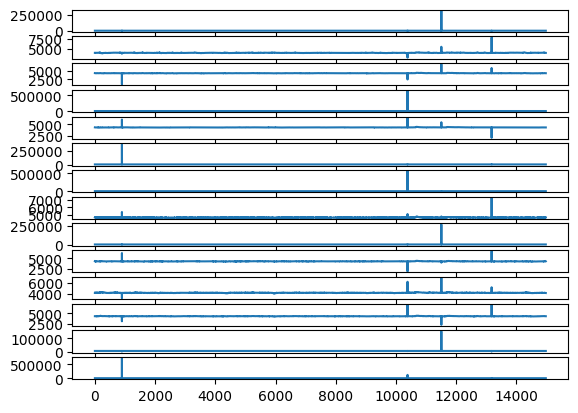

In [116]:
plt.figure()
for i in range(X.shape[1]):
	plt.subplot(X.shape[1], 1, i+1)
	plt.plot(X.iloc[:, i])

Removing of outliers by median filter

In [117]:
X_filtered = X.apply(lambda col: medfilt(col, kernel_size=5))

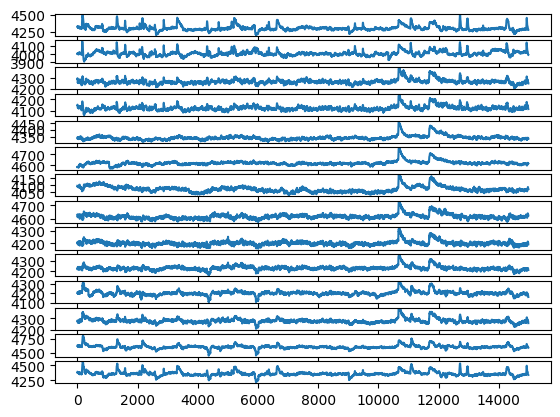

In [118]:
plt.figure()
for i in range(X_filtered.shape[1]):
	plt.subplot(X_filtered.shape[1], 1, i+1)
	plt.plot(X_filtered.iloc[:, i])

In [119]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

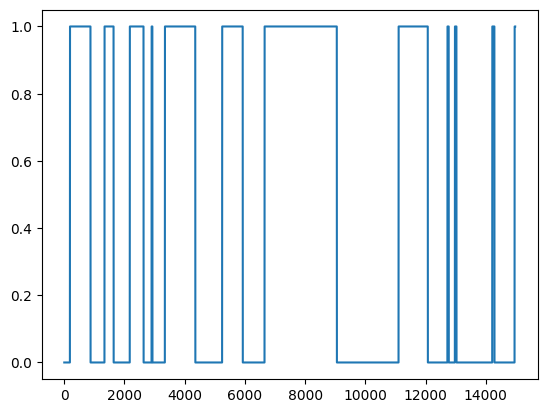

In [120]:
plt.plot(y)

## Selection of model 

In [121]:
y_values = y.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_values, test_size=0.2, shuffle=True)

In [122]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11984, 14), (2996, 14), (11984,), (2996,))

In [123]:
def print_result(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_train)
    print(f'Train accuracy: {accuracy_score(y_train, y_pred):.2f}')
    y_pred = model.predict(X_test)
    print(f'Test accuracy: {accuracy_score(y_test, y_pred):.2f}')


### Dummy

In [124]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_train)
print_result(dummy_clf, X_train, X_test, y_train, y_test)


Train accuracy: 0.55
Test accuracy: 0.57


### K-NN

In [125]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
print_result(knn_clf, X_train, X_test, y_train, y_test)

Train accuracy: 1.00
Test accuracy: 0.99


### SVM classifier

In [126]:
clf = SVC()
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 0.92
Test accuracy: 0.92


### Logistic regression

In [127]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 0.65
Test accuracy: 0.65


### Random forest

In [128]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 1.00
Test accuracy: 0.99


### Gradient boosting

In [129]:
clf = GradientBoostingClassifier()
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 0.87
Test accuracy: 0.86


### XGB

In [130]:
clf = XGBClassifier()
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 1.00
Test accuracy: 0.99


### Neural network

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=None, dropout_rate=0.2, use_batch_norm=True):
        super().__init__()
        
        if hidden_dims is None:
            hidden_dims = [64, 32]
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            layers.append(nn.ReLU())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))

        self.features = nn.Sequential(*layers)

        self._device = None
        self._is_fitted = False
        self._history = None
        
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
    
    def forward(self, x):
        return self.features(x)
    
    def fit(self, X, y, criterion=None, optimizer=None, 
            epochs=100, batch_size=32, lr=0.001,
            validation_data=None, early_stopping=None,
            verbose=True, device=None):

        if device is None:
            self._device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self._device = device
        
        if isinstance(X, np.ndarray):
            X = torch.FloatTensor(X)
        if isinstance(y, np.ndarray):
            y = torch.FloatTensor(y)
        
        if len(y.shape) == 1:
            y = y.unsqueeze(1)
        
        self.to(self._device)
        
        if criterion is None:
            criterion = nn.BCEWithLogitsLoss()
        
        if optimizer is None:
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        train_dataset = TensorDataset(X, y)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        val_loader = None
        if validation_data is not None:
            X_val, y_val = validation_data
            if isinstance(X_val, np.ndarray):
                X_val = torch.FloatTensor(X_val)
            if isinstance(y_val, np.ndarray):
                y_val = torch.FloatTensor(y_val)
            if len(y_val.shape) == 1:
                y_val = y_val.unsqueeze(1)
            val_dataset = TensorDataset(X_val, y_val)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        self._history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [] if validation_data is not None else None,
            'val_acc': [] if validation_data is not None else None
        }
        
        # Early stopping
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0

        for epoch in range(epochs):
            self.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self._device), batch_y.to(self._device)
                
                optimizer.zero_grad()
                outputs = self(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * batch_X.size(0)
                predicted = (torch.sigmoid(outputs) >= 0.5).float()
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            
            train_loss /= train_total
            train_acc = train_correct / train_total
            
            self._history['train_loss'].append(train_loss)
            self._history['train_acc'].append(train_acc)
            
            # Validation phase
            if val_loader is not None:
                self.eval()
                val_loss = 0.0
                val_correct = 0
                val_total = 0
                
                with torch.no_grad():
                    for batch_X, batch_y in val_loader:
                        batch_X, batch_y = batch_X.to(self._device), batch_y.to(self._device)
                        outputs = self(batch_X)
                        loss = criterion(outputs, batch_y)
                        
                        val_loss += loss.item() * batch_X.size(0)
                        predicted = (torch.sigmoid(outputs) >= 0.5).float()
                        val_total += batch_y.size(0)
                        val_correct += (predicted == batch_y).sum().item()
                
                val_loss /= val_total
                val_acc = val_correct / val_total
                
                self._history['val_loss'].append(val_loss)
                self._history['val_acc'].append(val_acc)
                
                # Early stopping check
                if early_stopping is not None:
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_model_state = {k: v.cpu().clone() for k, v in self.state_dict().items()}
                        patience_counter = 0
                    else:
                        patience_counter += 1
                        if patience_counter >= early_stopping:
                            if verbose:
                                print(f"Early stopping at epoch {epoch + 1}")
                            self.load_state_dict(best_model_state)
                            break
            
            if verbose:
                if epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1:
                    if val_loader is not None:
                        print(f'Epoch {epoch + 1}/{epochs} - '
                              f'Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - '
                              f'Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')
                    else:
                        print(f'Epoch {epoch + 1}/{epochs} - '
                              f'Loss: {train_loss:.4f} - Acc: {train_acc:.4f}')
        
        self._is_fitted = True
        return self
    
    def predict(self, X, threshold=0.5, batch_size=32):
        if not self._is_fitted:
            raise RuntimeError("Model is not fitted")
        
        if isinstance(X, np.ndarray):
            X = torch.FloatTensor(X)
        
        self.to(self._device)
        self.eval()
        
        dataset = TensorDataset(X)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        
        predictions = []
        
        with torch.no_grad():
            for (batch_X,) in loader:
                batch_X = batch_X.to(self._device)
                outputs = self(batch_X)
                probs = torch.sigmoid(outputs)
                preds = (probs >= threshold).float()
                predictions.append(preds.cpu().numpy())
        
        return np.vstack(predictions).flatten()
    
    def predict_proba(self, X, batch_size=32):
        if not self._is_fitted:
            raise RuntimeError("Model is not fitted")
        
        if isinstance(X, np.ndarray):
            X = torch.FloatTensor(X)
        
        self.to(self._device)
        self.eval()
        
        dataset = TensorDataset(X)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        
        probabilities = []
        
        with torch.no_grad():
            for (batch_X,) in loader:
                batch_X = batch_X.to(self._device)
                outputs = self(batch_X)
                probs = torch.sigmoid(outputs)
                probs_both = torch.cat([1 - probs, probs], dim=1)
                probabilities.append(probs_both.cpu().numpy())
        
        return np.vstack(probabilities)
    
    def score(self, X, y, batch_size=32):
        predictions = self.predict(X, batch_size=batch_size)
        if isinstance(y, np.ndarray):
            y = y.flatten()
        return (predictions == y).mean()
    
    def get_history(self):
        return self._history
    
    def save(self, path):
        torch.save({
            'model_state_dict': self.state_dict(),
            'input_dim': self.input_dim,
            'hidden_dims': self.hidden_dims,
            'dropout_rate': self.dropout_rate,
            'use_batch_norm': self.use_batch_norm,
            'is_fitted': self._is_fitted
        }, path)
    
    @classmethod
    def load(cls, path, device=None):
        checkpoint = torch.load(path, map_location=device or 'cpu')
        model = cls(
            input_dim=checkpoint['input_dim'],
            hidden_dims=checkpoint['hidden_dims'],
            dropout_rate=checkpoint['dropout_rate'],
            use_batch_norm=checkpoint['use_batch_norm']
        )
        model.load_state_dict(checkpoint['model_state_dict'])
        model._is_fitted = checkpoint['is_fitted']
        if device:
            model._device = device
        return model


In [144]:
model = BinaryClassifier(
        input_dim=14,
        hidden_dims=[64, 32],
        dropout_rate=0.3,
        use_batch_norm=True
    )
    
model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        lr=0.001,
        early_stopping=10,
        verbose=True
    )

print_result(model, X_train, X_test, y_train, y_test)
    

   

Epoch 1/50 - Loss: 0.5992 - Acc: 0.6766
Epoch 6/50 - Loss: 0.3617 - Acc: 0.8412
Epoch 11/50 - Loss: 0.3236 - Acc: 0.8596
Epoch 16/50 - Loss: 0.2931 - Acc: 0.8753
Epoch 21/50 - Loss: 0.2809 - Acc: 0.8801
Epoch 26/50 - Loss: 0.2767 - Acc: 0.8860
Epoch 31/50 - Loss: 0.2693 - Acc: 0.8894
Epoch 36/50 - Loss: 0.2699 - Acc: 0.8919
Epoch 41/50 - Loss: 0.2581 - Acc: 0.8934
Epoch 46/50 - Loss: 0.2497 - Acc: 0.8979
Epoch 50/50 - Loss: 0.2569 - Acc: 0.8921
Train accuracy: 0.96
Test accuracy: 0.95


## Baseline results

| Model | Train accuracy | Test accuracy | Training time |
|-|-|-|-|
| Dummy | 0.55 | 0.55 | ~0 |
| XGB | 1 | 0.99 | 0.5 |
| K-nn | 1 | 0.99 | 0.9 |
| Random forest | 1 | 0.99 | 2.6 |
| NN | 0.96 | 0.95 | 94 |
| SVM | 0.92 | 0.92 | 7.8 |
| Gradient boosting| 0.87 | 0.85 | 3.2 |
| Log reg | 0.65 | 0.65 | ~0 |

## Tuning with optuna

In [145]:
def objective(trial):
   learning_rate = trial.suggest_float('learning_rate', 1e-5, 1)
   max_depth = trial.suggest_int('max_depth', 1, 40)
   n_estimators = trial.suggest_int('n_estimators', 20, 500)
   
   xgb_clf = XGBClassifier(num_class=1,
                           max_depth=max_depth,
                           learning_rate=learning_rate,
                           n_estimators=n_estimators
                           )
   xgb_clf.fit(X_train, y_train) 
   predictions = xgb_clf.predict(X_train)
   acc = accuracy_score(y_train, predictions)
   return acc

In [146]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.CmaEsSampler())
study.optimize(objective, n_trials=100)
study.best_params

[I 2026-07-29 18:32:57,420] A new study created in memory with name: no-name-3088365a-2eec-41da-8641-238ab232ab9d
[I 2026-07-29 18:32:58,850] Trial 0 finished with value: 1.0 and parameters: {'learning_rate': 0.5643103641861407, 'max_depth': 14, 'n_estimators': 280}. Best is trial 0 with value: 1.0.
[I 2026-07-29 18:33:00,375] Trial 1 finished with value: 1.0 and parameters: {'learning_rate': 0.7212058273858222, 'max_depth': 17, 'n_estimators': 176}. Best is trial 0 with value: 1.0.
[I 2026-07-29 18:33:02,823] Trial 2 finished with value: 1.0 and parameters: {'learning_rate': 0.5165832925565436, 'max_depth': 25, 'n_estimators': 326}. Best is trial 0 with value: 1.0.
[I 2026-07-29 18:33:04,135] Trial 3 finished with value: 1.0 and parameters: {'learning_rate': 0.7045793233235564, 'max_depth': 14, 'n_estimators': 357}. Best is trial 0 with value: 1.0.
[I 2026-07-29 18:33:05,623] Trial 4 finished with value: 1.0 and parameters: {'learning_rate': 0.4784048767222283, 'max_depth': 22, 'n_est

{'learning_rate': 0.5643103641861407, 'max_depth': 14, 'n_estimators': 280}

In [147]:
clf = XGBClassifier(**study.best_params)
clf.fit(X_train, y_train)
print_result(clf, X_train, X_test, y_train, y_test)

Train accuracy: 1.00
Test accuracy: 0.99
